# Sign Language Digit Classification: Baseline CNN Model
> **Project Goal:** To establish a baseline model for sign language digit recognition using CNN.

### 1. Import Libraries
we import **TensorFlow** and other helper libraries for model building, data manipulation and visualization

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/MyDrive/data'
train_dir = os.path.join(base_dir, 'train')
valid_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

Mounted at /content/drive


### 2. Data Loading & Preprocessing
Using `image_dataset_from_directory`, we load our sign language images.

In [2]:
# Label definitions for the 10 sign language digits
class_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

# Load datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)

valid_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, shuffle=True, batch_size=32, image_size=(224, 224), class_names=class_names
)

print(f"Corrected Classes: {train_dataset.class_names}")

Found 559 files belonging to 10 classes.
Found 149 files belonging to 10 classes.
Found 329 files belonging to 10 classes.
Corrected Classes: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


### 3. Exploratory Data Analysis (EDA)
Visualizing a sample of the training data ensures that the labels are correctly mapped and the images are loaded as expected.

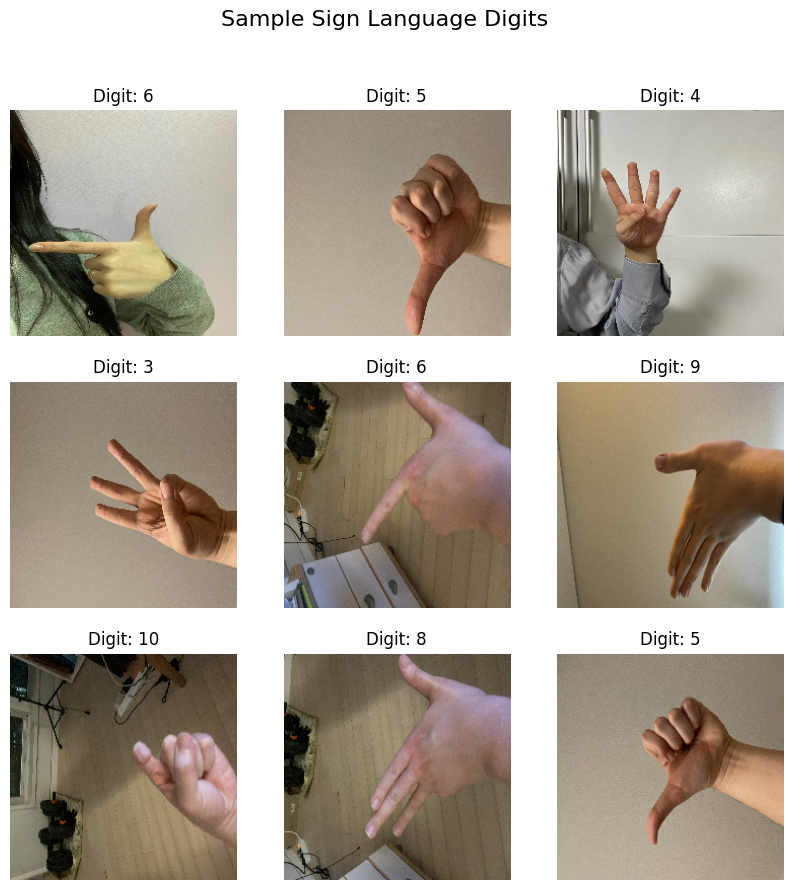

In [3]:
# Visualization
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Digit: {class_names[labels[i]]}")
        plt.axis("off")
plt.suptitle("Sample Sign Language Digits", fontsize=16)
plt.show()

### 4. Build CNN Model
* **Design**: A custom CNN using **Max Pooling** for parameter efficiency and **Dropout** to prevent overfitting.
* **Optimization**: Utilizes the **Adam optimizer** and **Sparse Categorical Crossentropy** for efficient 10-class digit classification.

In [4]:
# Build Model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 classes for digits 1-10
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,768,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,825,930 (10.78 MB)

 Trainable params: 2,825,930 (10.78 MB)

 Non-trainable params: 0 (0.00 B)

### 5. Training Model with Callbacks
To ensure the model generalizes well and avoids overfitting, we implement a robust training pipeline using Callbacks:
* **EarlyStopping** Monitors `validation loss` and automatically terminates the session if performance plateaus for 5 consecutive epochs, effectively preventing **overfitting**.
* **ModelCheckpoint** Ensures that only the **best-performing iteration** (the one with the lowest validation loss) is saved, protecting against performance fluctuations during the final epochs.

In [5]:
# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)

# Execute the training process
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=valid_dataset,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.1016 - loss: 3.4495 
Epoch 1: val_loss improved from None to 2.30409, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 239s 13s/step - accuracy: 0.0930 - loss: 2.8362 - val_accuracy: 0.1007 - val_loss: 2.3041
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0930 - loss: 2.3045
Epoch 2: val_loss did not improve from 2.30409
18/18 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.1091 - loss: 2.3030 - val_accuracy: 0.1007 - val_loss: 2.3298
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1348 - loss: 2.2992
Epoch 3: val_loss improved from 2.30409 to 2.30220, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.1503 - loss: 2.2812 - val_accuracy: 0.1409 - val_loss: 2.3022
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2597 - loss: 2.0999
E

### 6. Model Evaluation & Visualization
After training, we evaluate the model using a dedicated test set to measure its generalization capability. Learning curves (Accuracy/Loss) are plotted to diagnose the model's learning behavior.

11/11 ━━━━━━━━━━━━━━━━━━━━ 108s 10s/step - accuracy: 0.0973 - loss: 2.3321
Test Accuracy: 0.0973


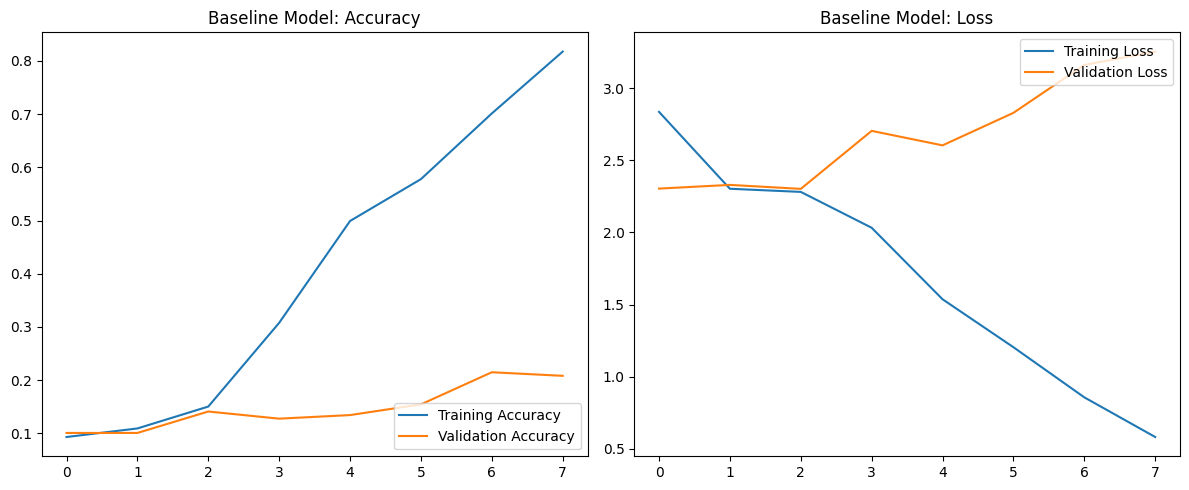

In [6]:
# Load the best model saved by ModelCheckpoint
best_model = tf.keras.models.load_model('best_model.keras')

# Perform evaluation
loss, acc = best_model.evaluate(test_dataset)
print(f"Test Accuracy: {acc:.4f}")

# Extract metrics from training history for visualization
acc_log = history.history['accuracy']
val_acc_log = history.history['val_accuracy']
loss_log = history.history['loss']
val_loss_log = history.history['val_loss']
epochs_range = range(len(acc_log))

# Plot performance metrics
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_log, label='Training Accuracy')
plt.plot(epochs_range, val_acc_log, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Baseline Model: Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_log, label='Training Loss')
plt.plot(epochs_range, val_loss_log, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Baseline Model: Loss')

plt.tight_layout()
plt.show()